## 機械学習の基礎

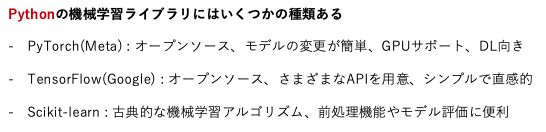

### 簡単な分類モデルを構築

`Irisデータセット`(有名な花の分類データセット)を使用して
アヤメの種類（setosa, versicolor, virginica）の3クラスに分類してみよう

インポート

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

データの準備

In [2]:
iris = load_iris()
X = iris.data  # 特徴量
y = iris.target  # ラベル

# データ分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# データの標準化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# データをテンソルに変換
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

データの可視化

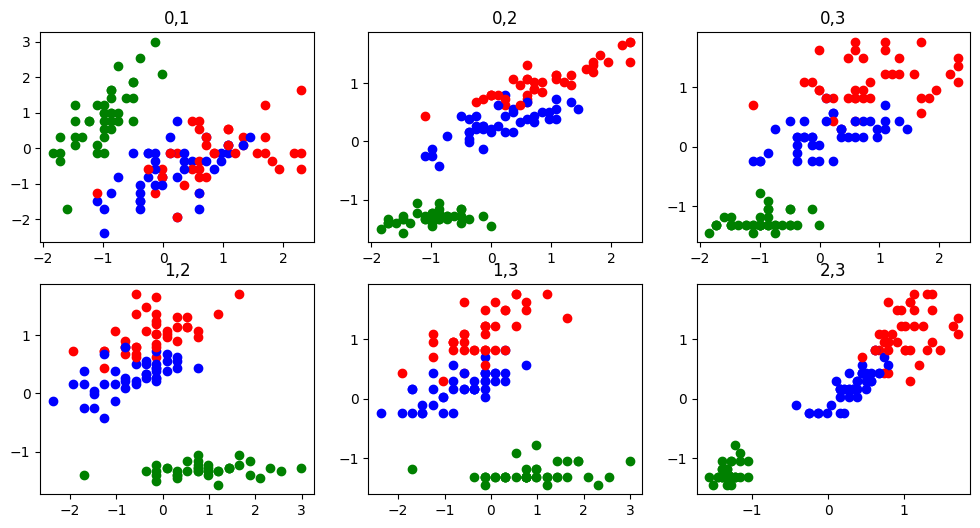

In [3]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=[12,6])
ax1 = fig.add_subplot(231)
ax1.set_title("0,1")
ax2 = fig.add_subplot(232)
ax2.set_title("0,2")
ax3 = fig.add_subplot(233)
ax3.set_title("0,3")
ax4 = fig.add_subplot(234)
ax4.set_title("1,2")
ax5 = fig.add_subplot(235)
ax5.set_title("1,3")
ax6 = fig.add_subplot(236)
ax6.set_title("2,3")

color=["green","blue","red"]

for i in range(len(X_train)):
    ax1.scatter(X_train[i,0],X_train[i,1],color=color[y_train[i]])
    ax2.scatter(X_train[i,0],X_train[i,2],color=color[y_train[i]])
    ax3.scatter(X_train[i,0],X_train[i,3],color=color[y_train[i]])
    ax4.scatter(X_train[i,1],X_train[i,2],color=color[y_train[i]])
    ax5.scatter(X_train[i,1],X_train[i,3],color=color[y_train[i]])
    ax6.scatter(X_train[i,2],X_train[i,3],color=color[y_train[i]])

モデルの定義

In [5]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super(IrisClassifier, self).__init__()
        self.fc1 = nn.Linear(4, 16)  # 入力次元: 4, 隠れ層: 16
        self.fc2 = nn.Linear(16, 3)  # 隠れ層: 16, 出力次元: 3 (クラス数)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)  # 出力層にSoftmaxは含めない（損失関数で処理）
        return x

# モデル、損失関数、オプティマイザの設定
model = IrisClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

モデルの学習

In [6]:
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 0.8057
Epoch [20/100], Loss: 0.5042
Epoch [30/100], Loss: 0.3629
Epoch [40/100], Loss: 0.2794
Epoch [50/100], Loss: 0.2068
Epoch [60/100], Loss: 0.1493
Epoch [70/100], Loss: 0.1126
Epoch [80/100], Loss: 0.0908
Epoch [90/100], Loss: 0.0777
Epoch [100/100], Loss: 0.0695


モデル評価

In [7]:
with torch.no_grad():
    model.eval()
    y_pred = model(X_test)
    y_pred_classes = torch.argmax(y_pred, axis=1)
    accuracy = (y_pred_classes == y_test).sum().item() / y_test.size(0)
    print(f'Accuracy: {accuracy:.4f}')

Accuracy: 1.0000


データを自分でモデルに入力してみる

In [8]:
data = [0.3545, -0.5851, 0.5578, 0.0222]
value = torch.tensor(data,dtype=torch.float32)
model.eval()
output = model(value)
pred_classes = int(torch.argmax(output, axis=0))
print(output)
print("クラス:",pred_classes, iris.target_names[pred_classes])

tensor([-4.0836,  3.0599, -0.7574], grad_fn=<ViewBackward0>)
クラス: 1 versicolor


ランダムにデータを作成してみる

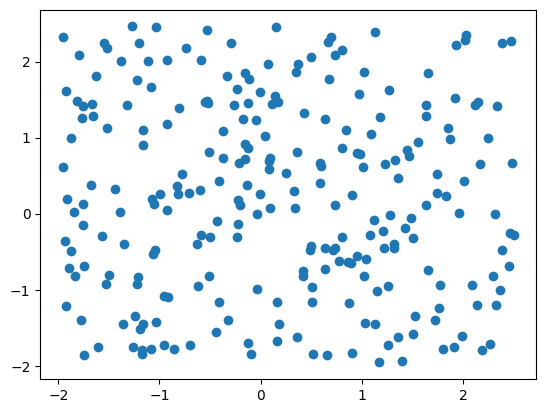

In [9]:
import random
import matplotlib.pyplot as plt
rand_list=[]
for i in range(1000):
    rand=random.uniform(-2, 2.5)
    rand_list.append(rand)
rand_list=torch.tensor(rand_list).view(-1,4)

plt.scatter(rand_list[:,0],rand_list[:,1])

ランダムに作成したデータをモデルに入力して予測クラスをプロットしてみる

/var/folders/pg/4xq55s1d0_s0df9m23wj8skm0000gn/T/ipykernel_22624/3957449852.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  value = torch.tensor(data,dtype=torch.float32)


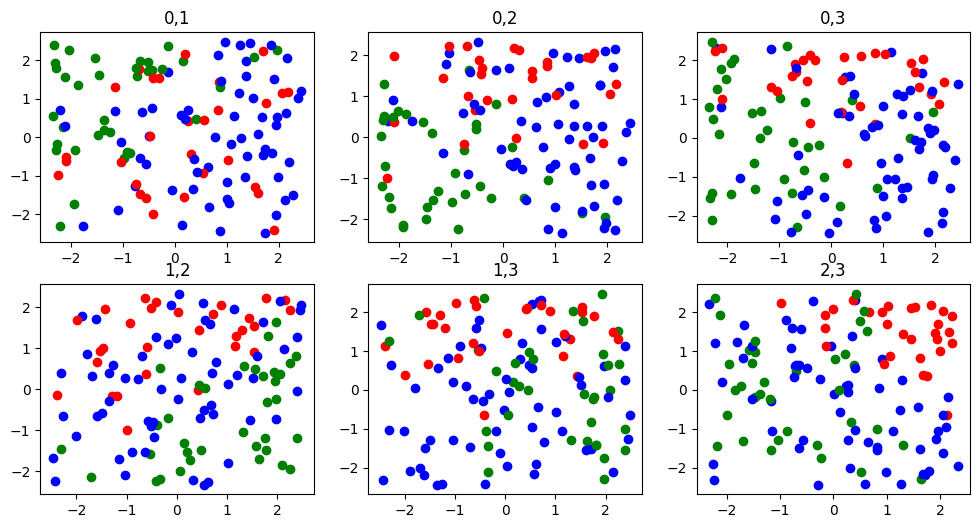

In [11]:
rand_list=[]
for i in range(500):
    rand=random.uniform(-2.5, 2.5)
    rand_list.append(rand)
rand_list=torch.tensor(rand_list).view(-1,4)

model.eval()

fig=plt.figure(figsize=[12,6])
ax1=fig.add_subplot(231)
ax1.set_title("0,1")
ax2=fig.add_subplot(232)
ax2.set_title("0,2")
ax3=fig.add_subplot(233)
ax3.set_title("0,3")
ax4=fig.add_subplot(234)
ax4.set_title("1,2")
ax5=fig.add_subplot(235)
ax5.set_title("1,3")
ax6=fig.add_subplot(236)
ax6.set_title("2,3")

for i in range(125):
    data=rand_list[i]
    value = torch.tensor(data,dtype=torch.float32)
    output = model(value)
    pred_classes = int(torch.argmax(output, axis=0))
    color=["green","blue","red"]
    ax1.scatter(float(value[0]),float(value[1]),color=color[pred_classes])
    ax2.scatter(float(value[0]),float(value[2]),color=color[pred_classes])
    ax3.scatter(float(value[0]),float(value[3]),color=color[pred_classes])
    ax4.scatter(float(value[1]),float(value[2]),color=color[pred_classes])
    ax5.scatter(float(value[1]),float(value[3]),color=color[pred_classes])
    ax6.scatter(float(value[2]),float(value[3]),color=color[pred_classes])

### 簡単な回帰モデルを構築

`California housing` (住宅価格の予測データセット)を使用して
入力特徴量から住宅価格（連続値）を予測

インポート

In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

データの準備

In [10]:
california_housing = fetch_california_housing()
X = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)  # 特徴量
y = california_housing.target

# データ分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# データの標準化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# データをテンソルに変換
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # 出力を列ベクトル化
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

モデルの定義

In [14]:
class BostonRegressor(nn.Module):
    def __init__(self):
        super(BostonRegressor, self).__init__()
        self.fc1 = nn.Linear(8, 128)  # 入力次元: 8, 隠れ層: 64
        self.fc2 = nn.Linear(128, 64)  # 入力次元: 64, 隠れ層: 64
        self.fc3 = nn.Linear(64, 16)  # 入力次元: 64, 隠れ層: 8
        self.fc4 = nn.Linear(16, 1)  # 出力次元: 1
        self.bn = nn.BatchNorm1d(16)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        #x = torch.relu(self.fc3(x))
        x = self.bn(self.fc3(x))
        x = self.fc4(x)  # 出力層
        return x

# モデル、損失関数、オプティマイザの設定
model = BostonRegressor()
criterion = nn.MSELoss()  # 平均二乗誤差
optimizer = optim.Adam(model.parameters(), lr=0.03)

モデルの学習

In [15]:
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if epoch==0 or epoch==10 or (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [1/1000], Loss: 6.4476
Epoch [11/1000], Loss: 1.8190
Epoch [100/1000], Loss: 0.2934
Epoch [200/1000], Loss: 0.2619
Epoch [300/1000], Loss: 0.2327
Epoch [400/1000], Loss: 0.2250
Epoch [500/1000], Loss: 0.2155
Epoch [600/1000], Loss: 0.2054
Epoch [700/1000], Loss: 0.2069
Epoch [800/1000], Loss: 0.2215
Epoch [900/1000], Loss: 0.1782
Epoch [1000/1000], Loss: 0.1672


モデルの評価

In [16]:
with torch.no_grad():
    model.eval()
    y_pred = model(X_test)
    mse = criterion(y_pred, y_test)
    print(f'Mean Squared Error(for test): {mse.item():.4f}')

Mean Squared Error(for test): 0.2793


モデルで学習データとテストデータを予測してみる

Text(0, 0.5, 'target')

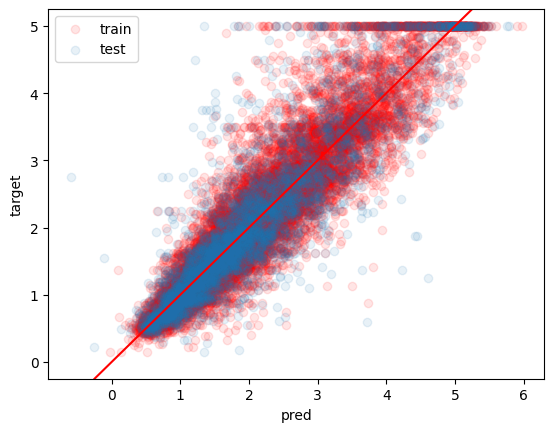

In [17]:
plt.scatter(model(X_train).detach().numpy(),y_train,color="red",alpha=0.1,label="train")
plt.scatter(model(X_test).detach().numpy(),y_test,alpha=0.1,label="test")
plt.legend()
plt.axline((0,0),(1,1),color="red")
plt.xlabel("pred")
plt.ylabel("target")

In [7]:
california_housing.target_names

['MedHouseVal']

,0
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [13]:
X[california_housing.target_names]=pd.DataFrame(y)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [14]:
X[X["MedHouseVal"]==5.0]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
4719,3.5556,25.0,4.022013,1.039308,1183.0,1.860063,34.06,-118.38,5.0
4823,2.3536,26.0,2.826563,1.000000,2543.0,3.973438,34.05,-118.31,5.0
5301,2.2444,20.0,2.977011,1.117595,2667.0,2.358090,34.06,-118.45,5.0
5308,4.7109,32.0,4.508393,1.043165,798.0,1.913669,34.05,-118.44,5.0
6776,6.0199,49.0,5.752412,0.926045,848.0,2.726688,34.12,-118.15,5.0
8290,3.6250,29.0,4.213518,1.087558,1059.0,1.626728,33.72,-118.16,5.0
8299,5.8408,52.0,5.411765,1.002451,791.0,1.938725,33.77,-118.14,5.0
8933,3.6121,29.0,4.006961,1.111369,741.0,1.719258,34.00,-118.48,5.0
9810,6.7770,23.0,8.103960,1.143564,1480.0,2.442244,36.58,-121.94,5.0
9850,1.2656,19.0,3.791908,1.156069,248.0,1.433526,36.60,-121.89,5.0
